### Setting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
import re

from pathlib import Path

BASE_DIR = Path().resolve().parent   
DATA_DIR = "G:/我的云端硬盘/NLP_project"
model_dir = "G:/我的云端硬盘/NLP_project/infrastructure_models"

# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = Path("/content/drive/MyDrive/NLP_project")
# model_dir = Path("/content/drive/MyDrive/NLP_project/infrastructure_models")

def show_full(df):
    """
    Fully display a DataFrame without any truncation.
    Works for any df[...] slice.
    """
    import pandas as pd
    from IPython.display import display

    with pd.option_context(
        "display.max_colwidth", None,
        "display.max_rows", None,
        "display.max_columns", None,
        "display.width", None
    ):
        display(df)

In [2]:
import torch
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using {device} as device.")

Using cpu as device.


### Load data

In [3]:
df_subchunks = pd.read_parquet(f"{DATA_DIR}/df_subchunks_raw.parquet")  

In [4]:
Industry_chunks = (
    df_subchunks.loc[df_subchunks["industry"] == "Infrastructure Systems",
                     ["chunk_uid", "url", "date", "title", "topic", "chunk_text"]]
    .copy()
    .rename(columns={"topic": "topic_v0"})
)
print(len(Industry_chunks))
Industry_chunks.head(2)

6653


,chunk_uid,url,date,title,topic_v0,chunk_text
84,39_0_0_0_0,https://economictimes.indiatimes.com/industry/...,2025-07-13,"""Don't think report is ok"": Aviation expert Sa...",99,"""Don't think report is ok"": Aviation expert Sa..."
85,39_0_0_1_0,https://economictimes.indiatimes.com/industry/...,2025-07-13,"""Don't think report is ok"": Aviation expert Sa...",99,We categorically reject this presumption and i...


### Bertopic

In [6]:
# ! pip install bertopic

In [8]:
### customize bertopic model
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from sklearn.cluster import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

RANDOM_STATE = 27

embedding_model = SentenceTransformer("thenlper/gte-small")  # , device="cuda"

umap_model = UMAP(
    n_neighbors=100, # smaller n_neighbors will -> local structure -> more detailed topics
    n_components=10, # smaller n_components will -> more coarse topics
    min_dist=0.1, # smaller min_dist will -> more clustered紧凑 topics
    metric="cosine",
    random_state=RANDOM_STATE
)

hdbscan_model = HDBSCAN(
    min_cluster_size=200, # smaller min_cluster_size will -> more detailed topics
    min_samples=100, # smaller min_samples -> easier get into topics -> more detailed topics, but also more noise
    metric="euclidean",
    cluster_selection_method="eom"
)

vectorizer_model = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,                 # 关键：别太高，保住 gpt/openai/llm
    max_df=0.70,              # 砍掉跨站模板词，但不至于太猛
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z\-]{2,}\b",
    # 你如果想加自定义 stopwords，见下方“可选增强”
)
ctfidf_model = ClassTfidfTransformer()

# All steps together
topic_model = BERTopic(
  embedding_model=embedding_model,          # Step 1 - Extract embeddings
  umap_model=umap_model,                    # Step 2 - Reduce dimensionality
  hdbscan_model=hdbscan_model,              # Step 3 - Cluster reduced embeddings
  vectorizer_model=vectorizer_model,        # Step 4 - Tokenize topics
  ctfidf_model=ctfidf_model,                # Step 5 - Extract topic words
)

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [9]:
docs = Industry_chunks["chunk_text"].tolist()
topics, probs = topic_model.fit_transform(docs)

In [10]:
Industry_topics = topic_model.get_topic_info()
Industry_chunks_topics = Industry_chunks.assign( topic=topics,  probability=probs)

In [14]:
show_full(Industry_topics[["Topic", 'Representation',"Count"]])

,Topic,Representation,Count
0,-1,"[landing gear, safran, atr, eric, lander, landings, designshack, hydraulic fluid, fastjet, parrot]",3
1,0,"[centers, data centers, data center, emissions, climate change, forecasting, plant, utilities, oil gas, natural gas]",4321
2,1,"[telecom, wireless, telco, ran, telcos, webinar, telecommunication, nokia, huawei, ericsson]",901
3,2,"[air india, crash, ahmedabad, express, plane crash, india express, dgca, investigation, crashed, flights]",569
4,3,"[zawya, arab, bri, flagship, road initiativechina, initiativechina, sell infocopyright, flagship global, bri reportbelt, infocopyright zawya]",489
5,4,"[aviation market, flights, contrails, jet, travelers, aviation industry, airways, planes, jets, air travel]",370


In [12]:
Industry_topics.to_csv(f"{DATA_DIR}/Infrastructure_specific/Industry_topics.csv", index=False)
Industry_chunks_topics.to_parquet(f"{DATA_DIR}/Infrastructure_specific/Industry_chunks_topics.parquet", index=False)

### Filter AI Impact related content

In [15]:
manual_related_topics = [0,1,4]
df_ai_impact = Industry_chunks_topics.loc[Industry_chunks_topics["topic"].isin(manual_related_topics)].copy()
print(len(df_ai_impact))

5592


In [16]:
df_ai_impact.to_parquet(f"{DATA_DIR}/Infrastructure_specific/infrastructure_df_ai_impact.parquet", index=False)

### Sentiment Analysis on chunk level

In [4]:
df_ai_impact = pd.read_parquet(f"{DATA_DIR}/Infrastructure_specific/infrastructure_df_ai_impact.parquet")

##### 1. use LLM to generate labels

In [5]:
df_ai_impact['topic'].value_counts()    

topic
0    4321
1     901
4     370
Name: count, dtype: int64

In [8]:
def topic_sample_n(topic_size):
    if topic_size >= 2000:
        return 250
    elif topic_size >= 900:
        return 150
    else:
        return 60

random_state = 38

df_ai_impact_sample = (
    df_ai_impact
    .groupby("topic", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), topic_sample_n(len(x))),
        random_state=random_state
    ))
    .reset_index(drop=True)
)

df_ai_impact_sample = df_ai_impact_sample[["chunk_uid", "topic", "chunk_text"]]
print(len(df_ai_impact_sample))
df_ai_impact_sample["topic"].value_counts()

460


C:\Users\ss363\AppData\Local\Temp\ipykernel_35644\366594644.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


topic
0    250
1    150
4     60
Name: count, dtype: int64

In [9]:
import os
import json
import pandas as pd
from jsonschema import validate, ValidationError

import openai
from openai import OpenAI
from tenacity import (
    retry,
    wait_exponential,
    stop_after_attempt,
    retry_if_exception_type
)

DS_API_KEY = "sk-a0a8781acaa74c52acd7e22c4249185c"
client = OpenAI(
    api_key=DS_API_KEY,
    base_url="https://api.deepseek.com",
)

In [10]:
system_msg = """
You are an expert analyst of infrastructure systems industries.

Your task is to evaluate how infrastructure systems and infrastructure-related
companies described in the text are expected to be impacted by AI
or AI-related developments.

Infrastructure systems include, but are not limited to:

- energy systems (electricity grids, power generation, utilities)
- data center infrastructure
- telecommunications networks
- transportation infrastructure (aviation systems, rail, logistics networks)
- digital infrastructure and cloud infrastructure
- water, utilities, and critical infrastructure systems
- infrastructure equipment providers and operators


You must classify the impact into EXACTLY ONE of the following:

1. "positively"

   The text suggests that AI or related technologies are expected to benefit
   infrastructure systems or infrastructure companies.

   This may include:

   - improved infrastructure efficiency
   - predictive maintenance of infrastructure assets
   - optimization of power grids or energy systems
   - improved network management in telecom infrastructure
   - better logistics and transportation optimization
   - improved capacity planning for data centers
   - automation of infrastructure monitoring and operations


2. "negatively"

   The text suggests that AI or related technologies are expected to harm,
   disrupt, or create risks for infrastructure systems or infrastructure companies.

   This may include:

   - rising electricity demand from AI data centers
   - strain on power grids or utilities
   - infrastructure capacity shortages
   - cybersecurity risks to critical infrastructure
   - infrastructure failures or operational disruptions
   - regulatory pressure on infrastructure expansion
   - environmental concerns from infrastructure growth


3. "hard-to-say"

   The text is neutral, mixed, uncertain, speculative, descriptive without
   clear directional impact, or presents both benefits and risks without a
   clear dominant direction.


### Decision Rules

- Focus on the MAIN directional implication of the text.
- Do not over-interpret minor phrases.
- If the text discusses both pros and cons without a clear dominant direction,
  choose "hard-to-say".
- If the text is mostly descriptive or factual without clear directional
  judgment, choose "hard-to-say".
- Ignore boilerplate, navigation fragments, or irrelevant web residue.
- Base your decision only on substantive content.


### Output Requirements

Return valid JSON with exactly two fields:

{
  "impact_label": "...",
  "reasoning": "..."
}

Where:
- "impact_label" must be one of: "positively", "negatively", "hard-to-say"
- "reasoning" should briefly summarize why the impact is classified that way.
"""


impact_user_template = """
Here is a text segment from the infrastructure systems industry domain:

{chunk_text}

Please determine whether the described infrastructure systems or companies
are expected to be impacted positively, negatively, or in an unclear/mixed way by AI.

Return JSON only.
"""


impact_schema = {
    "type": "object",
    "properties": {
        "impact_label": {
            "type": "string",
            "enum": ["positively", "negatively", "hard-to-say"]
        },
        "reasoning": {
            "type": "string"
        }
    },
    "required": ["impact_label", "reasoning"],
    "additionalProperties": False
}

In [11]:
@retry(
    retry=retry_if_exception_type((
        openai.RateLimitError,
        openai.APIConnectionError,
        openai.APITimeoutError,
        openai.InternalServerError
    )),
    wait=wait_exponential(multiplier=1, min=2, max=20),
    stop=stop_after_attempt(4),
    reraise=True
)
def get_answer(client, system_msg, user_msg, model="deepseek-chat"):
    completion = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        response_format={"type": "json_object"},
        temperature=0
    )
    content = completion.choices[0].message.content
    return json.loads(content)

VALID_LABELS = {"positively", "negatively", "hard-to-say"}

def normalize_impact_result(result):
    fallback = {
        "impact_label": "hard-to-say",
        "reasoning": "Unclear or insufficient directional evidence."
    }

    if not isinstance(result, dict):
        return fallback

    label = result.get("impact_label")
    reasoning = result.get("reasoning", "")

    if label not in VALID_LABELS:
        return fallback

    if not isinstance(reasoning, str) or not reasoning.strip():
        reasoning = fallback["reasoning"]

    normalized = {
        "impact_label": label,
        "reasoning": reasoning.strip()
    }

    try:
        validate(instance=normalized, schema=impact_schema)
        return normalized
    except ValidationError:
        return fallback

In [12]:
train_ai_impact_label = []

for idx, row in df_ai_impact_sample.iterrows():

    text = row["chunk_text"]

    user_msg = impact_user_template.format(
        chunk_text=text[:12000]
    )

    try:
        raw_result = get_answer(
            client=client,
            system_msg=system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )
        result = normalize_impact_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "impact_label": None,
            "reasoning": None,
            "api_status": f"failed: {err_msg}"
        }

        print(f"[Row {idx}] Failed: {e}")

    result["chunk_text"] = text
    result["topic"] = row["topic"]
    result['chunk_uid'] = row['chunk_uid']

    train_ai_impact_label.append(result)

In [13]:
df_train_ai_impact_label = pd.DataFrame(train_ai_impact_label)
display(df_train_ai_impact_label['impact_label'].value_counts())
imbalanced_df = df_train_ai_impact_label[df_train_ai_impact_label['impact_label'] == 'negatively'][['chunk_uid','chunk_text', 'reasoning']]
imbalanced_labels = df_train_ai_impact_label[df_train_ai_impact_label['impact_label'] == 'negatively']['chunk_uid'].to_list()
print(imbalanced_labels)
# show_full(imbalanced_df[['chunk_uid','reasoning']])

impact_label
positively     269
hard-to-say    128
negatively      63
Name: count, dtype: int64

['81808_2_0_0_1', '73085_0_0_2_0', '16594_0_0_0_0', '5655_0_0_0_2', '35484_0_0_3_1', '62196_0_0_0_2', '45383_0_0_0_0', '113432_0_0_0_1', '21857_0_0_0_2', '38715_0_0_0_0', '63341_0_1_0_1', '65812_1_0_0_2', '107312_0_0_0_2', '110143_0_0_0_2', '87984_1_0_0_1', '35484_0_0_0_0', '49621_0_0_0_1', '109858_0_0_0_0', '81816_0_0_0_1', '19133_0_0_0_0', '73796_0_0_0_1', '24819_0_0_0_0', '139369_1_0_0_1', '132529_0_0_0_1', '106451_1_0_0_0', '125276_0_0_0_0', '12168_0_0_0_2', '19136_1_0_1_1', '63362_3_0_0_0', '110143_0_0_0_0', '58661_0_0_0_1', '134070_1_0_0_0', '25068_0_0_0_0', '145961_0_1_0_0', '132175_0_0_0_0', '104895_0_0_0_2', '73790_0_1_0_0', '134488_0_0_0_0', '139369_1_0_0_0', '134253_0_0_0_0', '17283_4_0_0_1', '28021_1_1_0_0', '93183_1_0_1_0', '86341_0_0_0_0', '135596_0_0_0_1', '83668_0_0_0_0', '65838_0_0_0_0', '57835_0_0_0_0', '121551_0_0_0_0', '62060_1_0_0_1', '8635_0_0_0_3', '124785_1_0_0_0', '17283_4_0_1_1', '19152_1_0_0_1', '127160_1_1_0_0', '44308_0_0_0_1', '110974_2_0_0_2', '123006_0_0

In [14]:
df_train_ai_impact_label.to_parquet(f"{DATA_DIR}/Infrastructure_specific/infrastructure_ai_impact_train.parquet", index=False)

##### 2. finetune classifer

In [3]:
df_train_ai_impact_label = pd.read_parquet(f"{DATA_DIR}/Infrastructure_specific/infrastructure_ai_impact_train.parquet")
display(df_train_ai_impact_label['impact_label'].value_counts())

,count
impact_label,
positively,269
hard-to-say,128
negatively,63


In [4]:
label2id = {
    "negatively": 0,
    "hard-to-say": 1,
    "positively": 2
}

id2label = {v: k for k, v in label2id.items()}

df_train = (
    df_train_ai_impact_label.loc[df_train_ai_impact_label["impact_label"].isin(label2id.keys()), ["chunk_text", "impact_label"]]
    .rename(columns={"chunk_text": "text"})
    .copy()
)

df_train["label"] = df_train["impact_label"].map(label2id)
df_train = df_train[["text", "label"]].reset_index(drop=True)

df_train.head()

,text,label
0,Machine learning keeps solar one step ahead of...,2
1,This division of labour – reflected in the IPC...,2
2,About 37% of these grid technology startups ha...,1
3,The Empire State Building and Israel’s Azrieli...,2
4,Inquire Here Before Buying: https://www.allied...,2


In [6]:
from sklearn.model_selection import train_test_split
train_df, valid_df = train_test_split( df_train, test_size=0.17, random_state=42, stratify=df_train["label"])
print(train_df["label"].value_counts())
print(valid_df["label"].value_counts())

from datasets import Dataset, DatasetDict
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True), preserve_index=False)
valid_dataset = Dataset.from_pandas(valid_df.reset_index(drop=True), preserve_index=False)

dataset_dict = DatasetDict({ "train": train_dataset, "validation": valid_dataset})
dataset_dict

label
2    223
1    106
0     52
Name: count, dtype: int64
label
2    46
1    22
0    11
Name: count, dtype: int64


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 381
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 79
    })
})

In [11]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

max_len = 512
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_len,
        padding=False,
    )

tokenized_datasets = dataset_dict.map(tokenize_fn, batched=True)
tokenized_datasets

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/381 [00:00<?, ? examples/s]

Map:   0%|          | 0/79 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 381
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 79
    })
})

In [12]:
def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "macro_f1": f1,
        "macro_precision": precision,
        "macro_recall": recall
    }

trained_model_name = "infrastructure_ai_impact_classifier"

training_args = TrainingArguments(
    output_dir=f"{model_dir}/{trained_model_name}_ckpt",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    learning_rate=2e-5,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [13]:
trainer.train()
trainer.save_model(f"{model_dir}/{trained_model_name}")
tokenizer.save_pretrained(f"{model_dir}/{trained_model_name}")

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,No log,0.880309,0.582278,0.245333,0.194093,0.333333
2,No log,0.801999,0.607595,0.373572,0.362765,0.403162
3,0.850024,0.779131,0.645570,0.601865,0.601815,0.602108
4,0.850024,0.777127,0.670886,0.624867,0.622071,0.631752
5,0.519068,0.820429,0.658228,0.616378,0.621509,0.616601
6,0.519068,0.828667,0.670886,0.623735,0.631847,0.623847
7,0.315009,0.845291,0.645570,0.593184,0.604793,0.586298
8,0.315009,0.839675,0.658228,0.616378,0.621509,0.616601


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/NLP_project/infrastructure_models/infrastructure_ai_impact_classifier/tokenizer_config.json',
 '/content/drive/MyDrive/NLP_project/infrastructure_models/infrastructure_ai_impact_classifier/tokenizer.json')

              precision    recall  f1-score   support

  negatively       0.67      0.73      0.70        11
 hard-to-say       0.44      0.36      0.40        22
  positively       0.76      0.80      0.78        46

    accuracy                           0.67        79
   macro avg       0.62      0.63      0.62        79
weighted avg       0.66      0.67      0.66        79



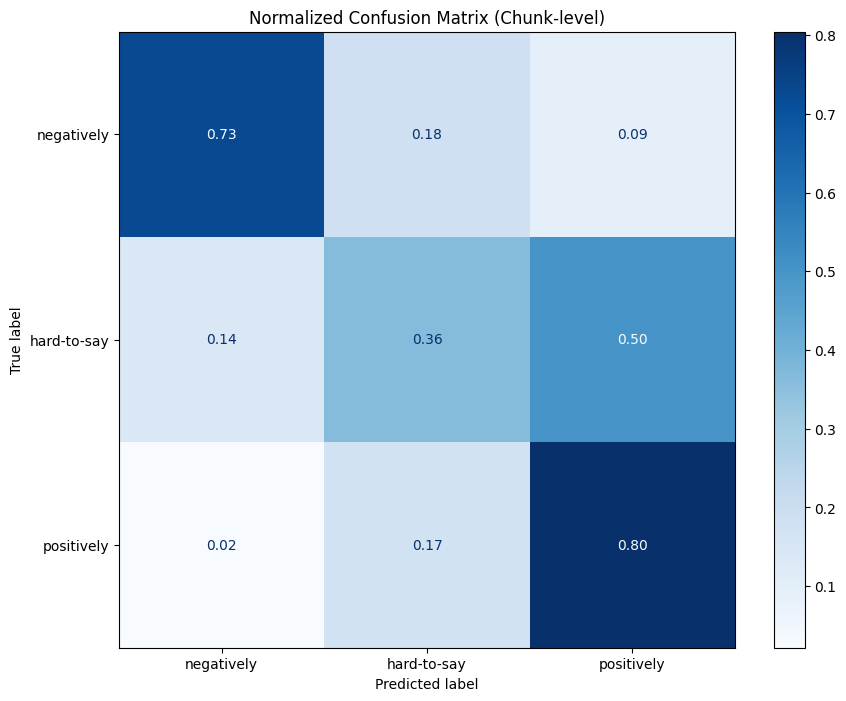

In [14]:
from sklearn.metrics import classification_report
val_pred = trainer.predict(tokenized_datasets["validation"])
val_preds = np.argmax(val_pred.predictions, axis=-1)
val_labels = np.array(tokenized_datasets["validation"]["label"])

print(classification_report(
    val_labels,
    val_preds,
    target_names=[id2label[i] for i in sorted(id2label.keys())],
    zero_division=0
))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(val_labels, val_preds, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[id2label[i] for i in sorted(id2label.keys())])
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title("Normalized Confusion Matrix (Chunk-level)")
plt.show()

##### 3. predict sentiment labels for all df_ai_impact chunks with the fine tuned model

In [15]:
df_ai_impact = pd.read_parquet(f"{DATA_DIR}/Infrastructure_specific/infrastructure_df_ai_impact.parquet")
df_ai_impact.head()

,chunk_uid,url,date,title,topic_v0,chunk_text,topic,probability
0,141_0_0_0_0,https://www.zerohedge.com/commodities/please-b...,2024-08-28,"""Please Bring Signs"": Marylanders To Protest A...",9,"""Please Bring Signs"": Marylanders To Protest A...",0,1.000000
1,141_0_0_0_1,https://www.zerohedge.com/commodities/please-b...,2024-08-28,"""Please Bring Signs"": Marylanders To Protest A...",9,Just remember that developing new NatGas gener...,0,1.000000
2,355_0_0_0_0,https://interestingengineering.com/culture/ai-...,2023-03-11,'3 raccoons in a trench coat': How AI boom cou...,9,'3 raccoons in a trench coat': How AI boom cou...,0,1.000000
3,367_0_0_0_0,https://www.businessgreen.com/news/4409714/ai-...,2025-02-11,'AI Energy Score': Salesforce launches new ben...,9,'AI Energy Score': Salesforce launches new ben...,0,0.895752
4,859_0_0_0_0,https://trt.global/world/article/18169106,2025-07-03,'New frontier': Aviation experts see AI revolu...,162,'New frontier': Aviation experts see AI revolu...,4,1.000000


In [16]:
print(df_ai_impact.shape)

(5592, 8)


In [17]:
from datasets import Dataset

df_ai_impact_pred = (
    df_ai_impact[['chunk_uid','url','date','title',"topic", "chunk_text"]]
    .rename(columns={"chunk_text": "text"})
    .reset_index(drop=True)
    .copy()
)

pred_dataset = Dataset.from_pandas(df_ai_impact_pred, preserve_index=False)
pred_dataset = pred_dataset.map(tokenize_fn, batched=True)

Map:   0%|          | 0/5592 [00:00<?, ? examples/s]

In [18]:
pred_output = trainer.predict(pred_dataset)
logits = pred_output.predictions

pred_ids = np.argmax(logits, axis=-1)
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()

# df_ai_impact_pred["pred_label_id"] = pred_ids
df_ai_impact_pred["pred_label"] = [id2label[i] for i in pred_ids]
df_ai_impact_pred["max_prob"] = probs.max(axis=1)

for i, label_name in id2label.items():
    df_ai_impact_pred[f"prob_{label_name}"] = probs[:, i]

print(df_ai_impact_pred.shape)
df_ai_impact_pred.head()

(5592, 11)


,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively
0,141_0_0_0_0,https://www.zerohedge.com/commodities/please-b...,2024-08-28,"""Please Bring Signs"": Marylanders To Protest A...",0,"""Please Bring Signs"": Marylanders To Protest A...",negatively,0.476813,0.476813,0.349312,0.173875
1,141_0_0_0_1,https://www.zerohedge.com/commodities/please-b...,2024-08-28,"""Please Bring Signs"": Marylanders To Protest A...",0,Just remember that developing new NatGas gener...,hard-to-say,0.545402,0.265743,0.545402,0.188855
2,355_0_0_0_0,https://interestingengineering.com/culture/ai-...,2023-03-11,'3 raccoons in a trench coat': How AI boom cou...,0,'3 raccoons in a trench coat': How AI boom cou...,hard-to-say,0.416817,0.396953,0.416817,0.186230
3,367_0_0_0_0,https://www.businessgreen.com/news/4409714/ai-...,2025-02-11,'AI Energy Score': Salesforce launches new ben...,0,'AI Energy Score': Salesforce launches new ben...,hard-to-say,0.658420,0.063807,0.658420,0.277773
4,859_0_0_0_0,https://trt.global/world/article/18169106,2025-07-03,'New frontier': Aviation experts see AI revolu...,4,'New frontier': Aviation experts see AI revolu...,positively,0.885948,0.032208,0.081845,0.885948


/tmp/ipykernel_17480/602985794.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


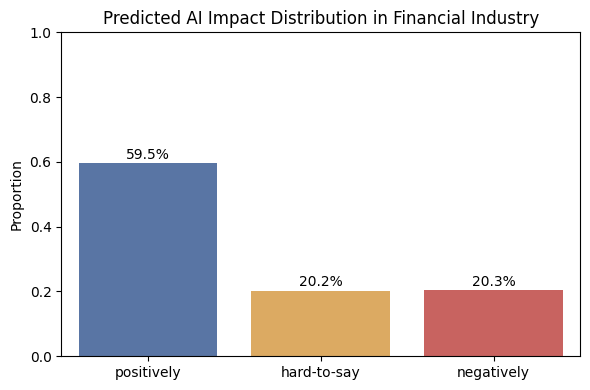

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ["positively", "hard-to-say", "negatively"]
dist = df_ai_impact_pred["pred_label"].value_counts(normalize=True).reindex(order)

plt.figure(figsize=(6, 4))

sns.barplot(
    x=dist.index,
    y=dist.values,
    palette=["#4C72B0", "#F0AD4E", "#D9534F"]
)

plt.ylabel("Proportion")
plt.xlabel("")
plt.title("Predicted AI Impact Distribution in Infrastructure Industry")
plt.ylim(0, 1)

for i, v in enumerate(dist.values):
    plt.text(i, v + 0.015, f"{v:.1%}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

In [20]:
df_ai_impact_pred.to_parquet(f"{model_dir}/{trained_model_name}_predictions.parquet", index=False)

### NER: Company and Technologies

In [3]:
df_ai_impact_pred = pd.read_parquet(f"{model_dir}/infrastructure_ai_impact_classifier_predictions.parquet")
print(df_ai_impact_pred.shape)

(5592, 11)


#### Positive impact

In [4]:
df_ai_impact_ner_sample = df_ai_impact_pred.loc[df_ai_impact_pred['pred_label'] == 'positively'].sample(500, random_state=38).reset_index(drop=True)

In [5]:
import os
import json
import pandas as pd
from jsonschema import validate, ValidationError

import openai
from openai import OpenAI
from tenacity import (
    retry,
    wait_exponential,
    stop_after_attempt,
    retry_if_exception_type
)

DS_API_KEY = "sk-a0a8781acaa74c52acd7e22c4249185c"
client = OpenAI(
    api_key=DS_API_KEY,
    base_url="https://api.deepseek.com",
)

In [6]:
entity_system_msg = """\
You are an information extraction system for infrastructure industry-related news articles.

The user will provide a text block from a news article related to infrastructure systems,
utilities, telecommunications networks, transportation infrastructure, or digital infrastructure.

Your task is to extract only the following:

1. organizations or companies in the infrastructure ecosystem explicitly mentioned in the text
2. AI-related technologies, capabilities, or infrastructure impact mechanisms explicitly mentioned in the text


## ORGANIZATIONS

Extract named organizations, companies, or institutions explicitly stated in the text.

These may include:

- utility companies
- electricity grid operators
- energy infrastructure providers
- telecommunications companies
- telecom equipment manufacturers
- data center operators
- airport or aviation infrastructure authorities
- logistics infrastructure providers


- NextEra Energy


## AI_TECHNOLOGIES_OR_MECHANISMS

Extract AI-related technologies or infrastructure impact mechanisms explicitly mentioned in the text.

This includes, but is not limited to:


AI technologies:

- generative AI
- large language models
- machine learning
- predictive analytics
- computer vision
- natural language processing
- digital twins
- anomaly detection systems


Infrastructure impact mechanisms:

- predictive maintenance
- grid optimization
- power demand forecasting
- infrastructure monitoring
- network optimization
- telecom network automation
- logistics optimization
- capacity planning for data centers
- automated infrastructure management
- energy efficiency optimization
- traffic flow optimization


## Directions

- Only extract information explicitly supported by the text.
- Do not infer entities that are not directly mentioned.
- Remove duplicates.
- Keep entity names concise and canonical when possible.
- Do not extract generic references such as “the company”, “the operator”, “utilities”, or “providers”
  unless a specific named entity is given.
- If none are present, return an empty list.
- Return valid JSON only.
"""


entity_user_template = """\
Title: {title}

Text:
{text}
"""

entity_json_schema = {
    "type": "object",
    "properties": {
        "organizations": {
            "type": "array",
            "items": {"type": "string"}
        },
        "ai_technologies_or_mechanisms": {
            "type": "array",
            "items": {"type": "string"}
        }
    },
    "required": ["organizations", "ai_technologies_or_mechanisms"],
    "additionalProperties": False
}

In [7]:
def normalize_entity_result(result):
    fallback = {
        "organizations": [],
        "ai_technologies_or_mechanisms": []
    }

    if not isinstance(result, dict):
        return fallback

    orgs = result.get("organizations", [])
    ai_items = result.get("ai_technologies_or_mechanisms", [])

    if not isinstance(orgs, list):
        orgs = []
    if not isinstance(ai_items, list):
        ai_items = []

    # 只保留非空字符串，并去重
    def clean_list(x):
        cleaned = []
        seen = set()
        for item in x:
            if isinstance(item, str):
                s = item.strip()
                if s and s not in seen:
                    cleaned.append(s)
                    seen.add(s)
        return cleaned

    normalized = {
        "organizations": clean_list(orgs),
        "ai_technologies_or_mechanisms": clean_list(ai_items)
    }

    try:
        validate(instance=normalized, schema=entity_json_schema)
        return normalized
    except ValidationError:
        return fallback
    
def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )

    content = response.choices[0].message.content
    return json.loads(content)

In [8]:
train_ai_impact_ner = []

for idx, row in df_ai_impact_ner_sample.iterrows():

    title = "" if pd.isna(row["title"]) else str(row["title"])
    text = "" if pd.isna(row["text"]) else str(row["text"])

    user_msg = entity_user_template.format(
        title=title[:500],
        text=text[:12000]
    )

    try:
        raw_result = generate_text(
            client=client,
            system_msg=entity_system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )

        result = normalize_entity_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "organizations": None,
            "ai_technologies_or_mechanisms": None,
            "api_status": f"failed: {err_msg}"
        }
        print(f"[Row {idx}] Failed: {e}")

    result["chunk_uid"] = row["chunk_uid"]
    result["title"] = title
    result["text"] = text
    result["pred_label"] = row["pred_label"]
    result["topic"] = row["topic"]

    train_ai_impact_ner.append(result)
    
df_ai_impact_ner_result = pd.DataFrame(train_ai_impact_ner)

In [9]:
df_ai_impact_ner_result.to_parquet(f"{DATA_DIR}/Infrastructure_specific/infrastructure_ai_impact_ner.parquet", index=False)

##### Organization 

In [11]:
df_ai_impact_ner_result_pos = pd.read_parquet(f"{DATA_DIR}/Infrastructure_specific/infrastructure_ai_impact_ner.parquet")

In [12]:
df_posorg_long = (
    df_ai_impact_ner_result_pos[["chunk_uid", "organizations"]]
    .explode("organizations")
)

df_posorg_long = df_posorg_long[df_posorg_long["organizations"].notna()].copy()
df_posorg_long["entity_raw"] = df_posorg_long["organizations"].astype(str).str.strip()
df_posorg_long = df_posorg_long[df_posorg_long["entity_raw"] != ""]

posorg_raw_counts = (
    df_posorg_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)
print(posorg_raw_counts.shape)
posorg_candidates = posorg_raw_counts.loc[posorg_raw_counts["raw_count"] >= 2, ["entity_raw",'raw_count']].copy()
print(posorg_candidates.shape)
posorg_candidates

(1019, 2)
(176, 2)


,entity_raw,raw_count
0,Microsoft,39
1,Google,36
2,OpenAI,23
3,Nvidia,19
4,IBM,15
...,...,...
171,Colorado State University,2
172,AST SpaceMobile,2
173,World Economic Forum,2
174,ANI,2


In [13]:
posorg_candidate_pairs = list(posorg_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
posorg_candidate_pairs_str = "\n".join( [f"- ({name}, {count})" for name, count in posorg_candidate_pairs])
posorg_candidate_pairs_str

"- (Microsoft, 39)\n- (Google, 36)\n- (OpenAI, 23)\n- (Nvidia, 19)\n- (IBM, 15)\n- (NVIDIA, 13)\n- (Amazon, 12)\n- (Vodafone, 11)\n- (Huawei, 11)\n- (Meta, 10)\n- (Ericsson, 10)\n- (Schneider Electric, 9)\n- (Constellation Energy, 9)\n- (Mavenir, 8)\n- (Google DeepMind, 8)\n- (Nokia, 8)\n- (SK Telecom, 7)\n- (Deutsche Telekom, 7)\n- (NOAA, 7)\n- (Vertiv, 7)\n- (Qualcomm, 6)\n- (TerraPower, 6)\n- (Google Cloud, 6)\n- (ZTE, 6)\n- (NASA, 6)\n- (Orange, 6)\n- (GSMA, 5)\n- (Capgemini, 5)\n- (ECMWF, 5)\n- (Hugging Face, 5)\n- (SAP, 5)\n- (Oklo, 5)\n- (Intel, 5)\n- (Oracle, 4)\n- (Kairos Power, 4)\n- (KDDI, 4)\n- (Boeing, 4)\n- (JLL, 4)\n- (Vistra, 4)\n- (Verizon, 4)\n- (TM Forum, 4)\n- (SoftBank, 4)\n- (Decisive Media, 4)\n- (Blue Planet, 4)\n- (Google Research, 4)\n- (AT&T, 4)\n- (DeepMind, 4)\n- (Samsung, 3)\n- (Siemens AG, 3)\n- (Stanford, 3)\n- (World Meteorological Organization, 3)\n- (Vodafone Idea, 3)\n- (Talen Energy, 3)\n- (Hansen, 3)\n- (Ecolibrium, 3)\n- (HPE, 3)\n- (Deloitte, 3)\

In [14]:
org_top_system_msg = """\
You are an organization name consolidation and ranking system.

The user will provide a list of organization names with mention counts extracted
from infrastructure systems industry AI-related news.

Your tasks:

1. Merge raw names that clearly refer to the same organization into one canonical organization name.
2. Classify canonical organizations into:
   - infrastructure_company
   - ai_company
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return only:
   - Top 10 infrastructure companies
   - Top 10 AI companies


Definitions:

### infrastructure_company
Organizations primarily operating in infrastructure systems industries.

Examples include:
- utility companies
- electricity grid operators
- energy infrastructure providers
- telecommunications operators
- telecom equipment manufacturers
- transportation infrastructure operators
- logistics infrastructure providers


### ai_company
Companies primarily focused on AI technologies, AI infrastructure,
or major technology companies involved in AI development.



Rules:
- Be conservative when merging.
- Do not merge different organizations.
- Use counts exactly as given.
- Media outlets, publications, and unclear entities should be ignored (not included in top lists).

Return valid JSON only.
"""

org_top_user_template = """\
Here is the list of (organization_name, mention_count):

{candidate_list}

Return JSON in this exact format:

{{
  "infrastructure_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ],
  "ai_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ]
}}
"""

org_top_json_schema = {
    "type": "object",
    "properties": {
        "infrastructure_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        },
        "ai_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        }
    },
    "required": ["infrastructure_top10", "ai_top10"],
    "additionalProperties": False
}

In [15]:
import json
import pandas as pd
from jsonschema import validate

def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )
    return json.loads(response.choices[0].message.content)

user_msg = org_top_user_template.format(candidate_list=posorg_candidate_pairs_str)

result_posorg = generate_text(
    client=client,
    system_msg=org_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_posorg, schema=org_top_json_schema)

In [16]:
industry_company_top10_pos = pd.DataFrame(result_posorg["infrastructure_top10"])
ai_company_top10_pos = pd.DataFrame(result_posorg["ai_top10"])

print("Infrastructure Top 10")
display(industry_company_top10_pos)

print("AI Top 10")
display(ai_company_top10_pos)

Public Top 10


,canonical_name,total_count,source_raw_names
0,Vodafone,14,"[Vodafone, Vodafone Idea]"
1,Huawei,11,[Huawei]
2,Ericsson,10,[Ericsson]
3,Schneider Electric,9,[Schneider Electric]
4,Constellation Energy,9,[Constellation Energy]
5,Mavenir,8,[Mavenir]
6,Nokia,11,"[Nokia, Nokia Corporation]"
7,SK Telecom,9,"[SK Telecom, SKT]"
8,Deutsche Telekom,7,[Deutsche Telekom]
9,Vertiv,7,[Vertiv]


AI Top 10


,canonical_name,total_count,source_raw_names
0,Microsoft,42,"[Microsoft, Microsoft Corporation]"
1,Google,54,"[Google, Google DeepMind, Google Cloud, Google..."
2,OpenAI,23,[OpenAI]
3,Nvidia,35,"[Nvidia, NVIDIA, NVIDIA Corporation]"
4,IBM,17,"[IBM, IBM Corporation]"
5,Amazon,15,"[Amazon, AWS]"
6,Meta,10,[Meta]
7,DeepMind,12,[DeepMind]
8,Hugging Face,5,[Hugging Face]
9,Anthropic,3,[Anthropic]


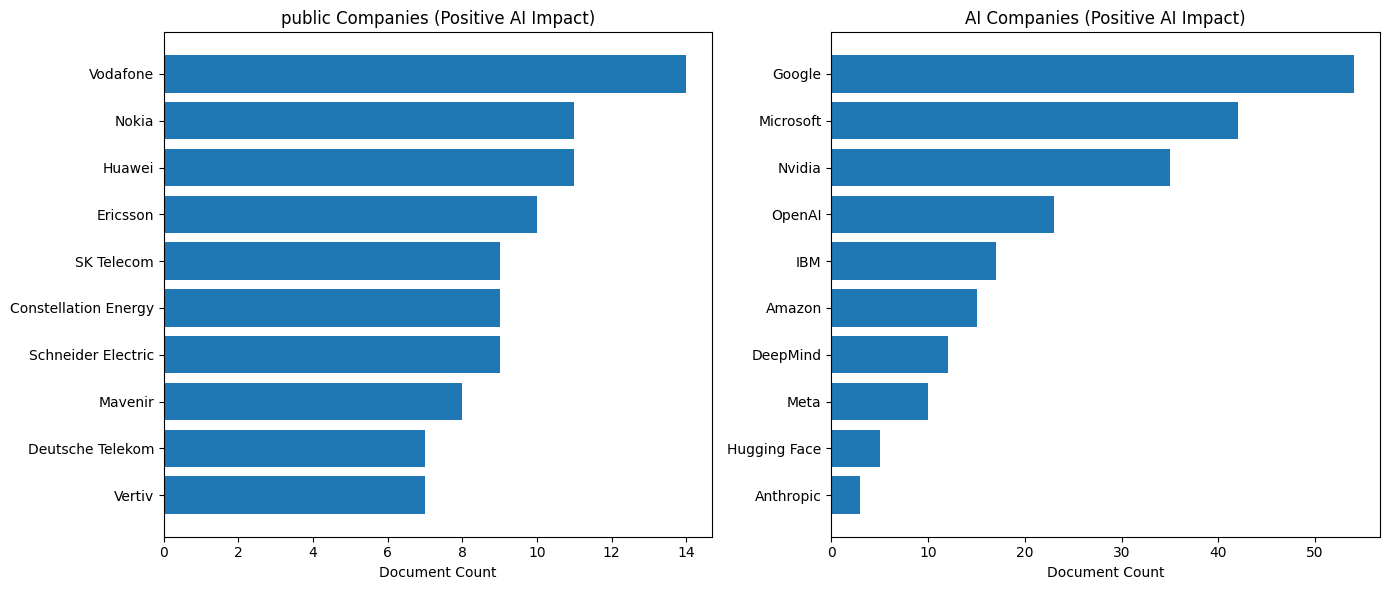

In [17]:
import matplotlib.pyplot as plt
import numpy as np

industry_df = industry_company_top10_pos.sort_values("total_count")
ai_df = ai_company_top10_pos.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# ---  Infrastructure ---

axes[0].barh(industry_df["canonical_name"], industry_df["total_count"])
axes[0].set_title("Infrastructure Companies (Positive AI Impact)")
axes[0].set_xlabel("Document Count")

# ---  AI ---
axes[1].barh(ai_df["canonical_name"], ai_df["total_count"])
axes[1].set_title("AI Companies (Positive AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

##### Technology and Mechanism 

In [18]:
df_posmech_long = (
    df_ai_impact_ner_result_pos[["chunk_uid", "ai_technologies_or_mechanisms"]]
    .explode("ai_technologies_or_mechanisms")
)
df_posmech_long = df_posmech_long[df_posmech_long["ai_technologies_or_mechanisms"].notna()].copy()
df_posmech_long["entity_raw"] = (
    df_posmech_long["ai_technologies_or_mechanisms"]
    .astype(str)
    .str.strip()
)
df_posmech_long = df_posmech_long[ df_posmech_long["entity_raw"] != ""]

posmech_raw_counts = (
    df_posmech_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)

print(posmech_raw_counts.shape)

posmech_candidates = posmech_raw_counts.loc[
    posmech_raw_counts["raw_count"] >= 2,
    ["entity_raw", "raw_count"]
].copy()

print(posmech_candidates.shape)

posmech_candidates

(849, 2)
(112, 2)


,entity_raw,raw_count
0,machine learning,97
1,generative AI,64
2,artificial intelligence,57
3,AI,54
4,predictive analytics,48
...,...,...
107,risk map,2
108,small language models,2
109,wide-scale AI deployment,2
110,artificial intelligence data centers,2


In [19]:
posmech_candidate_pairs = list(
    posmech_candidates[["entity_raw", "raw_count"]]
    .itertuples(index=False, name=None)
)
posmech_candidate_pairs_str = "\n".join([f"- ({name}, {count})" for name, count in posmech_candidate_pairs])
posmech_candidate_pairs_str

'- (machine learning, 97)\n- (generative AI, 64)\n- (artificial intelligence, 57)\n- (AI, 54)\n- (predictive analytics, 48)\n- (predictive maintenance, 35)\n- (energy efficiency optimization, 26)\n- (infrastructure monitoring, 25)\n- (large language models, 25)\n- (network optimization, 23)\n- (grid optimization, 21)\n- (AI models, 20)\n- (deep learning, 15)\n- (digital twins, 13)\n- (anomaly detection systems, 13)\n- (computer vision, 12)\n- (automation, 12)\n- (power demand forecasting, 12)\n- (automated infrastructure management, 11)\n- (natural language processing, 9)\n- (logistics optimization, 9)\n- (artificial intelligence (AI), 9)\n- (AI data centers, 8)\n- (capacity planning for data centers, 8)\n- (traffic flow optimization, 6)\n- (AI model, 6)\n- (network automation, 6)\n- (AI algorithms, 6)\n- (AI infrastructure, 6)\n- (telecom network automation, 6)\n- (AI applications, 5)\n- (AI tools, 5)\n- (ML, 5)\n- (demand forecasting, 5)\n- (ChatGPT, 5)\n- (Generative AI, 5)\n- (AI c

In [20]:
posmech_top_system_msg = """\
You are an AI technology and infrastructure systems impact mechanism consolidation system.

The user will provide a list of AI-related technologies or mechanisms with mention counts
extracted from infrastructure systems industry AI news.

Your tasks:

1. Merge raw names that clearly refer to the same concept into one canonical_name.
2. Classify canonical concepts into:
   - core_ai_technology
   - ai_infrastructure_mechanism
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return:
   - Top 10 core AI technologies
   - Top 10 AI infrastructure positive impact mechanisms


Definitions:

### core_ai_technology
Fundamental AI technologies, models, or technical approaches.

Examples:
- large language models
- generative AI
- machine learning
- deep learning
- neural networks
- predictive analytics
- computer vision
- natural language processing
- digital twins


### ai_infrastructure_mechanism
Applications, operational improvements, or system capabilities through which AI
positively affects infrastructure systems and infrastructure companies.

Examples:
- predictive maintenance
- infrastructure monitoring
- grid optimization
- power demand forecasting
- telecom network optimization
- telecom network automation
- logistics optimization
- traffic flow optimization
- capacity planning for data centers
- automated infrastructure management
- energy efficiency optimization
- anomaly detection in infrastructure systems


### other
Anything vague, unclear, or not clearly an AI technology or infrastructure mechanism.


Rules:
- Merge only when clearly referring to the same concept.
- Be conservative.
- Keep canonical names concise.
- Use counts exactly as provided.
- Only classify items as ai_infrastructure_mechanism when the infrastructure
  systems context is clear.
- machine learning, deep learning, and neural networks should be grouped under machine learning.
- ChatGPT should be grouped under large language models.

Return valid JSON only.
"""



mech_top_user_template = """\
Here is the list of (technology_or_mechanism_name, mention_count):

{candidate_list}

Return JSON in this exact format:

{{
  "core_ai_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ],
  "ai_mechanism_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ]
}}
"""

mech_top_json_schema = {
    "type": "object",
    "properties": {
        "core_ai_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        },
        "ai_mechanism_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        }
    },
    "required": ["core_ai_top10", "ai_mechanism_top10"],
    "additionalProperties": False
}

In [21]:
user_msg = mech_top_user_template.format(candidate_list=posmech_candidate_pairs_str)
result_posmech = generate_text(
    client=client,
    system_msg=posmech_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_posmech, schema=mech_top_json_schema)

In [22]:
technology_top10_pos = pd.DataFrame(result_posmech["core_ai_top10"])
mechanism_top10_pos = pd.DataFrame(result_posmech["ai_mechanism_top10"])

print("Core AI Technology Top 10")
display(technology_top10_pos)

print("AI Business Mechanism Top 10")
display(mechanism_top10_pos)

Core AI Technology Top 10


,canonical_name,total_count,source_raw_names
0,machine learning,121,"[machine learning, ML, Machine Learning, deep ..."
1,generative AI,72,"[generative AI, Generative AI, GenAI]"
2,artificial intelligence,70,"[artificial intelligence, AI, artificial intel..."
3,large language models,32,"[large language models, ChatGPT, ChatGPT-4, sm..."
4,predictive analytics,48,[predictive analytics]
5,digital twins,21,"[digital twins, digital twin, digital twin tec..."
6,computer vision,12,[computer vision]
7,natural language processing,9,[natural language processing]
8,foundation models,2,[foundation models]
9,diffusion models,2,[diffusion models]


AI Business Mechanism Top 10


,canonical_name,total_count,source_raw_names
0,predictive maintenance,35,[predictive maintenance]
1,energy efficiency optimization,28,"[energy efficiency optimization, energy optimi..."
2,infrastructure monitoring,28,"[infrastructure monitoring, monitoring, real-t..."
3,grid optimization,25,"[grid optimization, grid management, grid anal..."
4,network optimization,23,[network optimization]
5,power demand forecasting,17,"[power demand forecasting, demand forecasting,..."
6,automated infrastructure management,11,[automated infrastructure management]
7,logistics optimization,9,[logistics optimization]
8,capacity planning for data centers,8,[capacity planning for data centers]
9,traffic flow optimization,6,[traffic flow optimization]


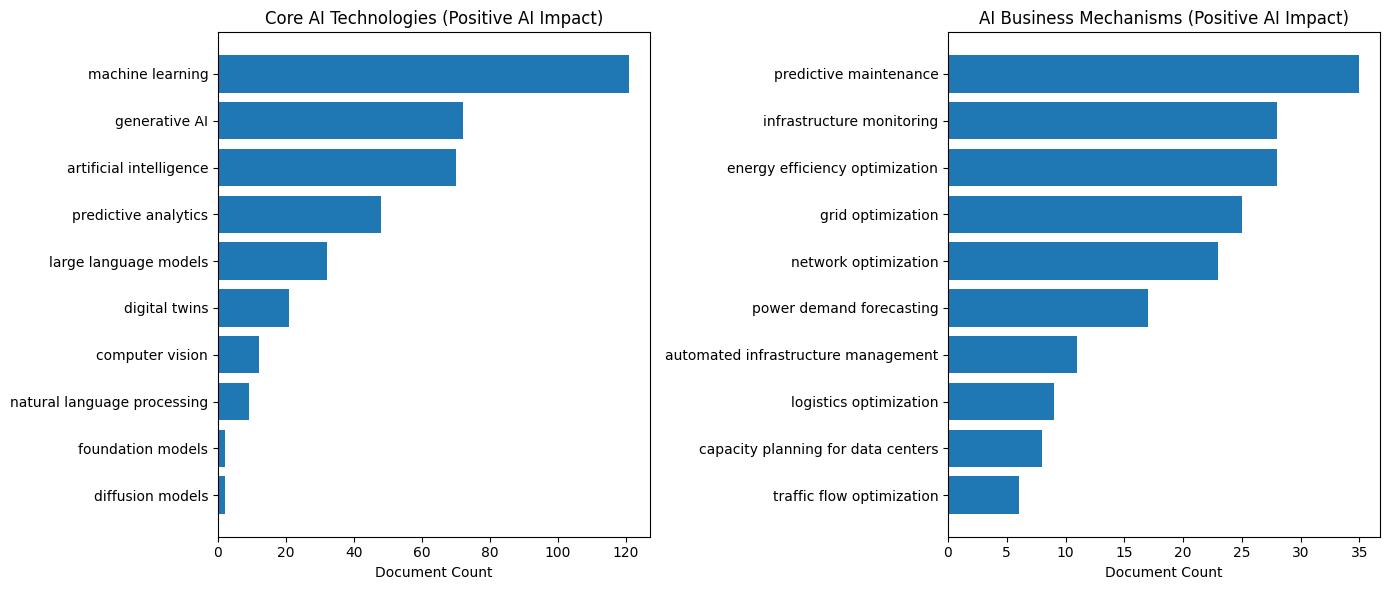

In [23]:
import matplotlib.pyplot as plt

tech_df = technology_top10_pos.sort_values("total_count")
mech_df = mechanism_top10_pos.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Core AI Technology ---
axes[0].barh(tech_df["canonical_name"], tech_df["total_count"])
axes[0].set_title("Core AI Technologies (Positive AI Impact)")
axes[0].set_xlabel("Document Count")

# --- AI Business Mechanism ---
axes[1].barh(mech_df["canonical_name"], mech_df["total_count"])
axes[1].set_title("AI Business Mechanisms (Positive AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

#### Negative impact

In [24]:
df_ai_negative_impact_ner_sample = df_ai_impact_pred.loc[df_ai_impact_pred['pred_label'] == 'negatively'].sample(500, random_state=43).reset_index(drop=True)
print(len(df_ai_negative_impact_ner_sample))

500


In [25]:
neg_entity_system_msg = """\
You are an information extraction system for infrastructure systems industry-related news articles.

The user will provide a text block from a news article related to infrastructure systems,
utilities, telecommunications networks, transportation infrastructure, or digital infrastructure.
This dataset is focused on negative AI impact.

Your task is to extract only the following:

1. organizations or companies in the infrastructure ecosystem explicitly mentioned in the text
2. AI-related technologies, capabilities, or NEGATIVE infrastructure impact mechanisms explicitly mentioned in the text


## ORGANIZATIONS

Extract named organizations or companies explicitly stated in the text.

These may include:

- utility companies
- electricity grid operators
- energy infrastructure providers
- telecommunications operators
- telecom equipment manufacturers
- transportation infrastructure operators
- logistics infrastructure providers


## AI_TECHNOLOGIES_OR_MECHANISMS

Extract:

- AI-related technologies or capabilities explicitly mentioned in the text
- AI-related NEGATIVE infrastructure impact mechanisms explicitly mentioned in the text


Examples of technologies / capabilities:

- generative AI
- large language models
- machine learning
- predictive analytics
- computer vision
- anomaly detection systems
- digital twins


Examples of NEGATIVE impact mechanisms:

- rising electricity demand from AI data centers
- power grid stress
- energy infrastructure strain
- infrastructure capacity shortages
- data center power consumption concerns
- environmental impact of infrastructure expansion
- infrastructure deployment delays
- infrastructure investment pressure
- telecom network congestion
- infrastructure cybersecurity risks
- critical infrastructure vulnerability
- operational disruption of infrastructure systems


## Directions

- Focus especially on negative AI-related mechanisms, risks, harms, and downsides.
- Only extract information explicitly supported by the text.
- Do not infer entities that are not directly mentioned.
- Remove duplicates.
- Keep entity names concise and canonical when possible.
- Do not extract generic references such as “the company”, “the operator”, “utilities”, or “providers”
  unless a specific named entity is given.
- If none are present, return an empty list.
- Return valid JSON only.
"""

In [26]:
train_ai_negative_impact_ner = []

for idx, row in df_ai_negative_impact_ner_sample.iterrows():

    title = "" if pd.isna(row["title"]) else str(row["title"])
    text = "" if pd.isna(row["text"]) else str(row["text"])

    user_msg = entity_user_template.format(
        title=title[:500],
        text=text[:12000]
    )

    try:
        raw_result = generate_text(
            client=client,
            system_msg=neg_entity_system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )

        result = normalize_entity_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "organizations": None,
            "ai_technologies_or_mechanisms": None,
            "api_status": f"failed: {err_msg}"
        }
        print(f"[Row {idx}] Failed: {e}")

    result["chunk_uid"] = row["chunk_uid"]
    result["title"] = title
    result["text"] = text
    result["pred_label"] = row["pred_label"]
    result["topic"] = row["topic"]

    train_ai_negative_impact_ner.append(result)
    
df_ai_negative_impact_ner_result = pd.DataFrame(train_ai_negative_impact_ner)

In [27]:
df_ai_negative_impact_ner_result.to_parquet(f"{DATA_DIR}/Infrastructure_specific/infrastructure_ai_negative_impact_ner.parquet", index=False)

##### Organization 

In [28]:
df_negorg_long = (
    df_ai_negative_impact_ner_result[["chunk_uid", "organizations"]]
    .explode("organizations")
)

df_negorg_long = df_negorg_long[df_negorg_long["organizations"].notna()].copy()
df_negorg_long["entity_raw"] = df_negorg_long["organizations"].astype(str).str.strip()
df_negorg_long = df_negorg_long[df_negorg_long["entity_raw"] != ""]

negorg_raw_counts = (
    df_negorg_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)
print(negorg_raw_counts.shape)
negorg_candidates = negorg_raw_counts.loc[negorg_raw_counts["raw_count"] >= 2, ["entity_raw",'raw_count']].copy()
print(negorg_candidates.shape)
negorg_candidates

(578, 2)
(170, 2)


,entity_raw,raw_count
0,Microsoft,103
1,Google,99
2,Amazon,63
3,OpenAI,51
4,Meta,43
...,...,...
165,EQT,2
166,EdgeNebula,2
167,World Economic Forum,2
168,ANDE,2


In [29]:
negorg_candidate_pairs = list(negorg_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
negorg_candidate_pairs_str = "\n".join( [f"- ({name}, {count})" for name, count in negorg_candidate_pairs])
negorg_candidate_pairs_str

"- (Microsoft, 103)\n- (Google, 99)\n- (Amazon, 63)\n- (OpenAI, 51)\n- (Meta, 43)\n- (International Energy Agency, 25)\n- (Nvidia, 17)\n- (Oracle, 14)\n- (Constellation Energy, 13)\n- (PJM, 12)\n- (Constellation, 11)\n- (Apple, 11)\n- (Alliance for Secure AI, 10)\n- (Dominion Energy, 10)\n- (Amazon Web Services, 9)\n- (CNBC, 9)\n- (PJM Interconnection, 8)\n- (Goldman Sachs, 8)\n- (Department of Energy, 8)\n- (Union of Concerned Scientists, 7)\n- (Energy Department, 7)\n- (X-energy, 7)\n- (Carnegie Mellon University, 6)\n- (Nuclear Regulatory Commission, 6)\n- (Alphabet, 6)\n- (Lawrence Berkeley National Laboratory, 6)\n- (Hugging Face, 6)\n- (ECL, 6)\n- (xAI, 6)\n- (Crusoe, 5)\n- (Grid Strategies, 5)\n- (Energy Information Administration, 5)\n- (IEA, 5)\n- (Kairos Power, 5)\n- (Georgia Power, 5)\n- (Wood Mackenzie, 5)\n- (Edison Electric Institute, 5)\n- (University of California, Riverside, 5)\n- (White House, 5)\n- (U.S. Department of Energy, 4)\n- (BloombergNEF, 4)\n- (BlackRock, 4)

In [30]:
user_msg = org_top_user_template.format(candidate_list=negorg_candidate_pairs_str)

result_negorg = generate_text(
    client=client,
    system_msg=org_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_negorg, schema=org_top_json_schema)

In [31]:
industry_company_top10_neg = pd.DataFrame(result_negorg["infrastructure_top10"])
ai_company_top10_neg = pd.DataFrame(result_negorg["ai_top10"])

print("Infrastructure Top 10")
display(industry_company_top10_neg)

print("AI Top 10")
display(ai_company_top10_neg)

public Top 10


,canonical_name,total_count,source_raw_names
0,PJM Interconnection,20,"[PJM, PJM Interconnection]"
1,Constellation Energy,24,"[Constellation Energy, Constellation]"
2,Dominion Energy,12,"[Dominion Energy, Dominion]"
3,Equinix,4,[Equinix]
4,Georgia Power,5,[Georgia Power]
5,National Grid,3,[National Grid]
6,PG&E,4,[PG&E]
7,Schneider Electric,3,[Schneider Electric]
8,Digital Realty,3,[Digital Realty]
9,Vantage Data Centers,3,[Vantage Data Centers]


AI Top 10


,canonical_name,total_count,source_raw_names
0,Microsoft,103,[Microsoft]
1,Google,101,"[Google, Alphabet, Alphabet Inc., Alphabet's G..."
2,Amazon,75,"[Amazon, Amazon Web Services, Amazon Web Servi..."
3,OpenAI,51,[OpenAI]
4,Meta,47,"[Meta, Meta Platforms, Facebook]"
5,Nvidia,20,"[Nvidia, NVIDIA]"
6,Oracle,14,[Oracle]
7,Apple,11,[Apple]
8,Hugging Face,6,[Hugging Face]
9,xAI,6,[xAI]


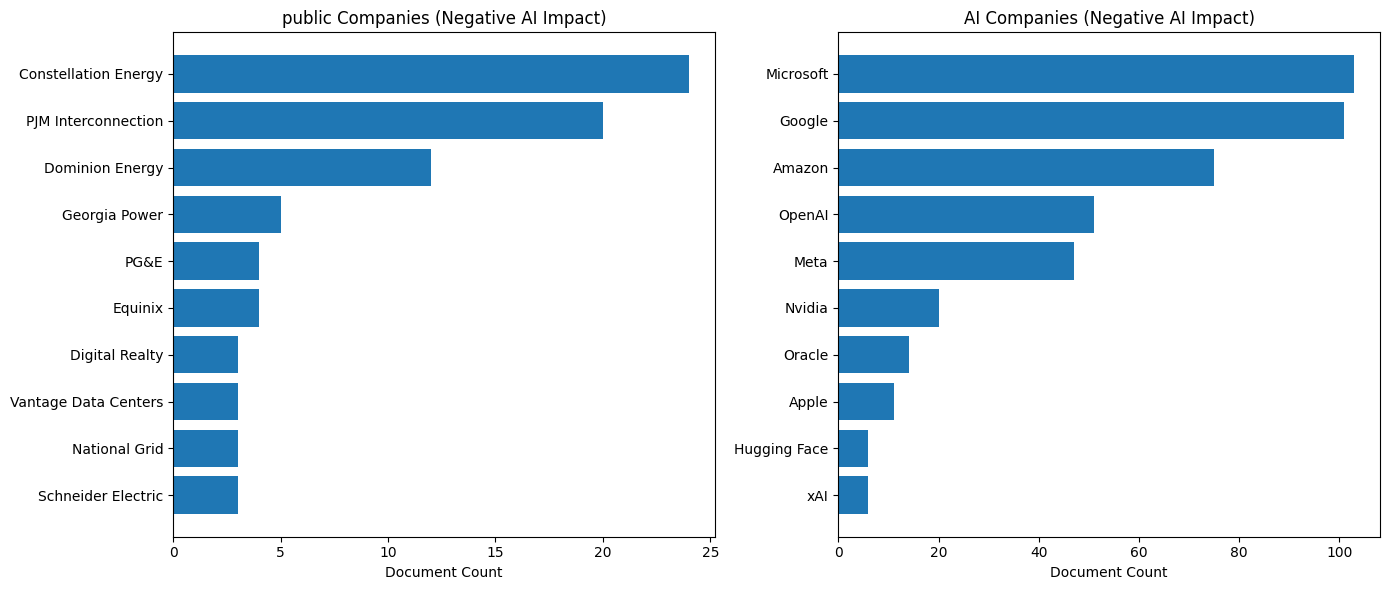

In [32]:
import matplotlib.pyplot as plt
import numpy as np

industry_df = industry_company_top10_neg.sort_values("total_count")
ai_df = ai_company_top10_neg.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# ---  Infrastructure ---
axes[0].barh(industry_df["canonical_name"], industry_df["total_count"])
axes[0].set_title("Infrastructure Companies (Negative AI Impact)")
axes[0].set_xlabel("Document Count")

# ---  AI ---
axes[1].barh(ai_df["canonical_name"], ai_df["total_count"])
axes[1].set_title("AI Companies (Negative AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

##### Technology and Mechanism 

In [33]:
df_ai_mech_long_neg = (
    df_ai_negative_impact_ner_result[["chunk_uid", "ai_technologies_or_mechanisms"]]
    .explode("ai_technologies_or_mechanisms")
)
df_ai_mech_long_neg = df_ai_mech_long_neg[df_ai_mech_long_neg["ai_technologies_or_mechanisms"].notna()].copy()
df_ai_mech_long_neg["entity_raw"] = (
    df_ai_mech_long_neg["ai_technologies_or_mechanisms"]
    .astype(str)
    .str.strip()
)
df_ai_mech_long_neg = df_ai_mech_long_neg[ df_ai_mech_long_neg["entity_raw"] != ""]

neg_ai_mech_raw_counts = (
    df_ai_mech_long_neg.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)

print(neg_ai_mech_raw_counts.shape)

neg_ai_mech_candidates = neg_ai_mech_raw_counts.loc[
    neg_ai_mech_raw_counts["raw_count"] >= 2,
    ["entity_raw", "raw_count"]
].copy()

print(neg_ai_mech_candidates.shape)

neg_ai_mech_candidates

(322, 2)
(49, 2)


,entity_raw,raw_count
0,rising electricity demand from AI data centers,351
1,infrastructure capacity shortages,246
2,data center power consumption concerns,234
3,power grid stress,217
4,energy infrastructure strain,205
5,environmental impact of infrastructure expansion,197
6,infrastructure investment pressure,113
7,infrastructure deployment delays,70
8,operational disruption of infrastructure systems,37
9,critical infrastructure vulnerability,36


In [34]:
neg_candidate_pairs = list( neg_ai_mech_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
neg_candidate_pairs_str = "\n".join([f"- ({name}, {count})" for name, count in neg_candidate_pairs])
neg_candidate_pairs_str

"- (rising electricity demand from AI data centers, 351)\n- (infrastructure capacity shortages, 246)\n- (data center power consumption concerns, 234)\n- (power grid stress, 217)\n- (energy infrastructure strain, 205)\n- (environmental impact of infrastructure expansion, 197)\n- (infrastructure investment pressure, 113)\n- (infrastructure deployment delays, 70)\n- (operational disruption of infrastructure systems, 37)\n- (critical infrastructure vulnerability, 36)\n- (AI data centers, 34)\n- (generative AI, 33)\n- (artificial intelligence, 28)\n- (large language models, 16)\n- (AI, 12)\n- (high energy costs, 9)\n- (machine learning, 7)\n- (AI models, 6)\n- (AI data center, 5)\n- (infrastructure cybersecurity risks, 5)\n- (artificial intelligence boom, 4)\n- (data centers, 4)\n- (artificial intelligence data centers, 4)\n- (AI chatbots, 4)\n- (telecom network congestion, 4)\n- (electricity customers might see their bills increase as utilities plan for massive data projects on the grid, 3

In [35]:
neg_mech_top_system_msg = """\
You are an AI technology and infrastructure systems impact mechanism consolidation system.

The user will provide a list of AI-related technologies or mechanisms with mention counts
extracted from infrastructure systems industry AI news.

Your tasks:

1. Merge raw names that clearly refer to the same concept into one canonical_name.
2. Classify canonical concepts into:
   - core_ai_technology
   - ai_infrastructure_mechanism
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return:
   - Top 10 core AI technologies
   - Top 10 AI infrastructure negative impact mechanisms


Definitions:

### core_ai_technology
Fundamental AI technologies, models, or technical approaches.


### ai_infrastructure_mechanism
Operational, capacity, environmental, or systemic mechanisms
through which AI negatively affects infrastructure systems
or infrastructure companies.


Examples of NEGATIVE infrastructure mechanisms:
- rising electricity demand from AI data centers
- power grid stress
- energy infrastructure strain
- infrastructure capacity shortages
- data center power consumption concerns
- environmental impact of infrastructure expansion
- telecom network congestion
- infrastructure cybersecurity risks
- critical infrastructure vulnerability
- operational disruption of infrastructure systems
- infrastructure investment pressure
- infrastructure deployment delays


### other
Anything vague, unclear, or not clearly technology or mechanism.


Rules:
- Merge only when clearly referring to the same concept.
- Be conservative.
- Keep canonical names concise.
- Use counts exactly as provided.
- Only classify items as ai_infrastructure_mechanism when the infrastructure
  systems context is clear.
- machine learning, deep learning and neural networks should be grouped under machine learning.
- ChatGPT should be grouped under large language models.

Return valid JSON only.
"""

In [36]:
user_msg = mech_top_user_template.format(candidate_list=neg_candidate_pairs_str)
result_negmech = generate_text(
    client=client,
    system_msg=neg_mech_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_negmech, schema=mech_top_json_schema)

In [37]:
technology_top10_neg = pd.DataFrame(result_negmech["core_ai_top10"])
ai_mechanism_top10_neg = pd.DataFrame(result_negmech["ai_mechanism_top10"])

print("Core AI Technology Top 10")
display(technology_top10_neg)

print("AI Business Negative Impact Mechanism Top 10")
display(ai_mechanism_top10_neg)

Core AI Technology Top 10


,canonical_name,total_count,source_raw_names
0,artificial intelligence,52,"[artificial intelligence, AI, artificial intel..."
1,generative AI,36,"[generative AI, generative artificial intellig..."
2,large language models,19,"[large language models, ChatGPT, AI chatbots]"
3,machine learning,7,[machine learning]
4,AI models,8,"[AI models, large AI models, AI model]"
5,cloud computing,2,[cloud computing]
6,AI compute,2,[AI compute]
7,AI operations,2,[AI operations]
8,AI's resource usage,2,[AI's resource usage]
9,AI-driven data centers,2,[AI-driven data centers]


AI Business Negative Impact Mechanism Top 10


,canonical_name,total_count,source_raw_names
0,rising electricity demand from AI data centers,353,[rising electricity demand from AI data center...
1,infrastructure capacity shortages,246,[infrastructure capacity shortages]
2,data center power consumption concerns,234,[data center power consumption concerns]
3,power grid stress,217,[power grid stress]
4,energy infrastructure strain,205,[energy infrastructure strain]
5,environmental impact of infrastructure expansion,197,[environmental impact of infrastructure expans...
6,infrastructure investment pressure,113,[infrastructure investment pressure]
7,infrastructure deployment delays,70,[infrastructure deployment delays]
8,operational disruption of infrastructure systems,37,[operational disruption of infrastructure syst...
9,critical infrastructure vulnerability,36,[critical infrastructure vulnerability]


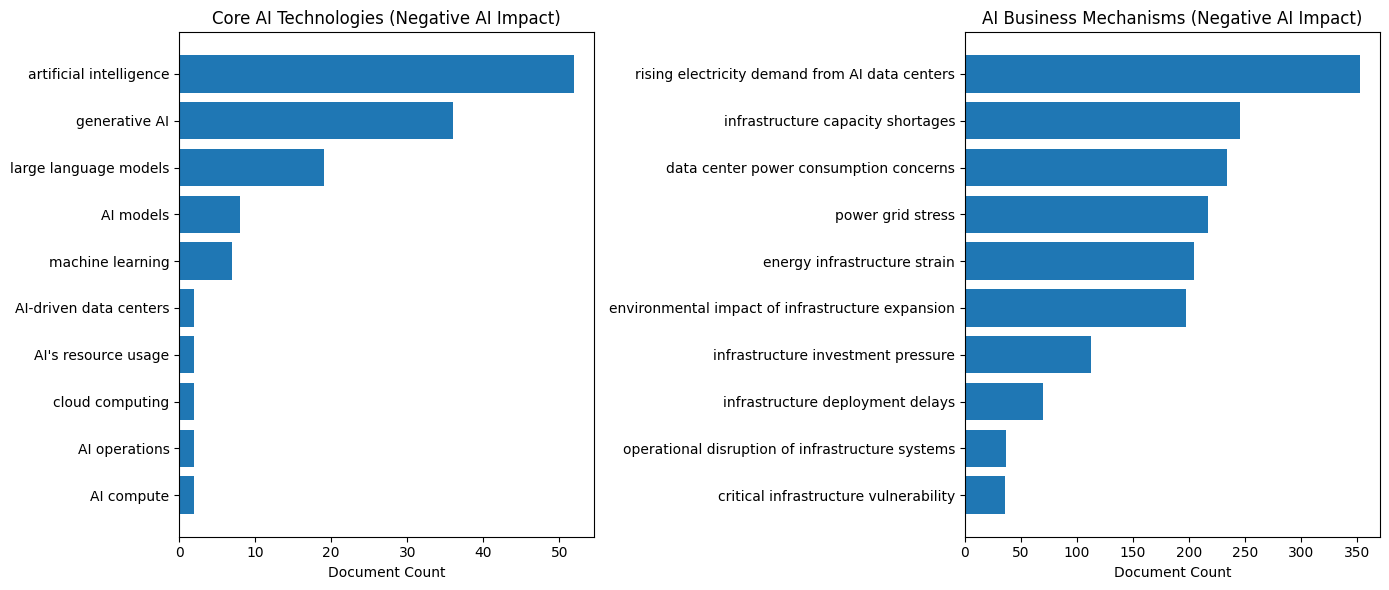

In [38]:
import matplotlib.pyplot as plt

tech_df = technology_top10_neg.sort_values("total_count")
mech_df = ai_mechanism_top10_neg.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Core AI Technology ---
axes[0].barh(tech_df["canonical_name"], tech_df["total_count"])
axes[0].set_title("Core AI Technologies (Negative AI Impact)")
axes[0].set_xlabel("Document Count")

# --- AI Business Mechanism ---
axes[1].barh(mech_df["canonical_name"], mech_df["total_count"])
axes[1].set_title("AI Business Mechanisms (Negative AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

### Aggregated Sentiment Anaysis

In [ ]:
df_ai_impact_pred = pd.read_parquet(f"{model_dir}/infrastructure_ai_impact_classifier_predictions.parquet")

#### Topic Aggregation

In [39]:
Industry_topics = pd.read_csv(f"{DATA_DIR}/Infrastructure_specific/Industry_topics.csv")
Industry_chunks_topics = pd.read_parquet(f"{DATA_DIR}/Infrastructure_specific/Industry_chunks_topics.parquet")

In [52]:
display(Industry_topics)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,35,-1_ai-powered face_including lack_tech reporte...,"['ai-powered face', 'including lack', 'tech re...",['The companies building foundation models wil...
1,0,3161,0_schumer_bipartisan_newsom_majority leader,"['schumer', 'bipartisan', 'newsom', 'majority ...","[""In closed forum, tech titans to give senator..."
2,1,2411,1_high-risk_european commission_fundamental ri...,"['high-risk', 'european commission', 'fundamen...",['How do they work and will they affect people...
3,2,1962,2_law firms_schwartz_legal research_legal prof...,"['law firms', 'schwartz', 'legal research', 'l...","['10th Circ. Ends Civil Rights Suit, Sanctions..."
4,3,1299,3_election commission_kramer_federal election_...,"['election commission', 'kramer', 'federal ele...",['The Federal Election Commission has begun a ...
5,4,1179,4_bletchley_safety summit_bletchley park_sunak...,"['bletchley', 'safety summit', 'bletchley park...",['Sunak says agreements at UK summit tip the b...
6,5,682,5_ont_calgary_alberta_quebec,"['ont', 'calgary', 'alberta', 'quebec', 'rcmp'...","[""B.C. premier sees promise in AI | CTV News\n..."
7,6,342,6_guterres_secretary-general_guterres said_gen...,"['guterres', 'secretary-general', 'guterres sa...",['UN chief appoints 39-member panel to advise ...


##### AI Impact

In [40]:
ai_impact_topic_id = [0,1,4]
ai_impact_topics = Industry_topics[Industry_topics["Topic"].isin(ai_impact_topic_id)][['Topic','Representation','Representative_Docs']].copy()
ai_impact_topics

,Topic,Representation,Representative_Docs
1,0,"['centers', 'data centers', 'data center', 'em...","[""It’s a data center hub that will be approxim..."
2,1,"['telecom', 'wireless', 'telco', 'ran', 'telco...",['The future of telecom Part 2: Proactive 5G a...
5,4,"['aviation market', 'flights', 'contrails', 'j...",['Contrails — the lines behind airplanes — are...


In [41]:
topic_summary_system_msg = """\
You are a topic interpretation system.

The user will provide:
- topic keywords
- representative documents

Your task:
Summarize what this topic is mainly about in one concise sentence (max 20 words).

Return plain text only.
"""
topic_summary_user_template = """\
Topic keywords:
{keywords}

Representative documents:
{docs}

What is this topic mainly about?
"""
def generate_text_plain(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0
    )
    return response.choices[0].message.content.strip()
summaries = []

for _, row in ai_impact_topics.iterrows():
    
    keywords = row["Representation"]
    docs = row["Representative_Docs"]
    
    user_msg = topic_summary_user_template.format(
        keywords=str(keywords),
        docs=str(docs)[:4000]   # 防止太长
    )
    
    summary = generate_text_plain(
        client=client,
        system_msg=topic_summary_system_msg,
        user_msg=user_msg
    )
    
    summaries.append(summary)

ai_impact_topics["topic_summary"] = summaries
show_full(ai_impact_topics[["Topic", "topic_summary"]])

,Topic,topic_summary
1,0,Data centers' high water consumption and emissions raise environmental concerns amid climate change.
2,1,"This topic focuses on the evolution of wireless telecom networks, including 5G, AI integration, and infrastructure from major vendors."
5,4,"This topic is about using artificial intelligence to reduce aviation's climate impact, particularly by minimizing heat-trapping contrails from flights."


In [42]:
df_ai_impact_pred["doc_id"] = df_ai_impact_pred["chunk_uid"].astype(str).str.split("_").str[0]
df_ai_impact_pred["doc_id"] = df_ai_impact_pred["doc_id"].astype(int)

display(df_ai_impact_pred.head(2))

,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively,doc_id
0,141_0_0_0_0,https://www.zerohedge.com/commodities/please-b...,2024-08-28,"""Please Bring Signs"": Marylanders To Protest A...",0,"""Please Bring Signs"": Marylanders To Protest A...",negatively,0.476813,0.476813,0.349312,0.173875,141
1,141_0_0_0_1,https://www.zerohedge.com/commodities/please-b...,2024-08-28,"""Please Bring Signs"": Marylanders To Protest A...",0,Just remember that developing new NatGas gener...,hard-to-say,0.545402,0.265743,0.545402,0.188855,141


In [43]:
# Group by topic and pred_label, and count the nunique of doc_id in each group
aiimpact_topic_label_doc_counts = (
    df_ai_impact_pred
    .groupby(["topic", "pred_label"])["doc_id"]
    .nunique()
    .rename("doc_counts")
    .reset_index()
    .pivot(index="topic", columns="pred_label", values="doc_counts")
    .fillna(0)
    .reset_index()
)
display(aiimpact_topic_label_doc_counts)


# percentage calculation
aiimpact_topic_label_doc_prop = (
    aiimpact_topic_label_doc_counts
    .set_index("topic")
    .pipe(lambda x: x.div(x.sum(axis=1), axis=0))
    .reset_index()
)

aiimpact_topic_label_doc_prop_pct = aiimpact_topic_label_doc_prop.copy()
cols = aiimpact_topic_label_doc_prop_pct.columns.drop("topic")
aiimpact_topic_label_doc_prop_pct[cols] = (
    aiimpact_topic_label_doc_prop_pct[cols]
    .mul(100)
    .round(2)
    .astype(str)
    .add("%")
)
aiimpact_topic_label_doc_prop_pct

pred_label,topic,hard-to-say,negatively,positively
0,0,622,526,1096
1,1,134,6,351
2,4,46,12,159


pred_label,topic,hard-to-say,negatively,positively
0,0,27.72%,23.44%,48.84%
1,1,27.29%,1.22%,71.49%
2,4,21.2%,5.53%,73.27%


In [44]:
# Topic-level impact polarity score
aiimpact_topic_label_doc_prop["impact_score"] = (
    aiimpact_topic_label_doc_prop["positively"]
    - aiimpact_topic_label_doc_prop["negatively"]
)

display(aiimpact_topic_label_doc_prop)

pred_label,topic,hard-to-say,negatively,positively,impact_score
0,0,0.277184,0.234403,0.488414,0.254011
1,1,0.272912,0.012220,0.714868,0.702648
2,4,0.211982,0.055300,0.732719,0.677419


The correction assumes that the observed predicted label distribution is a noisy transformation of the true label distribution.

The confusion matrix describes how true labels are converted into predicted labels.

By inverting this transformation, we estimate the underlying true distribution of labels at the topic level.

In [45]:
labels = ["negatively", "hard-to-say", "positively"]

C = np.array([
    [0.73, 0.18, 0.09],
    [0.14, 0.36, 0.50],
    [0.02, 0.17, 0.80]
])

C_inv = np.linalg.inv(C.T)

def correct_distribution(row):
    pred_dist = row[labels].values.astype(float)
    corrected = C_inv @ pred_dist
    corrected = np.clip(corrected, 0, 1)
    corrected = corrected / corrected.sum()
    return corrected

corrected_values = np.vstack(aiimpact_topic_label_doc_prop.apply(correct_distribution, axis=1))

aiimpact_topic_label_doc_prop_corrected = aiimpact_topic_label_doc_prop.copy().drop(columns='impact_score')
aiimpact_topic_label_doc_prop_corrected[labels] = corrected_values

aiimpact_topic_label_doc_prop_corrected["impact_score_corrected"] = (
    aiimpact_topic_label_doc_prop_corrected["positively"]
    - aiimpact_topic_label_doc_prop_corrected["negatively"]
)
display(aiimpact_topic_label_doc_prop_corrected)

pred_label,topic,hard-to-say,negatively,positively,impact_score_corrected
0,0,0.549630,0.208281,0.242088,0.033807
1,1,0.488985,0.000000,0.511015,0.511015
2,4,0.211606,0.013350,0.775044,0.761695


#### Time Aggregation

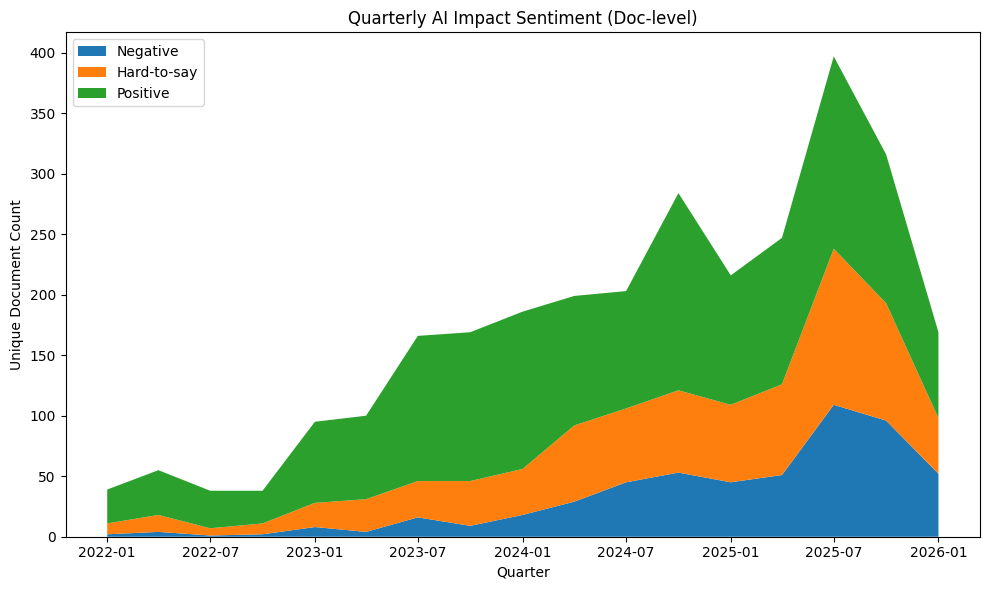

In [46]:
df_ai_impact_pred["date"] = pd.to_datetime(df_ai_impact_pred["date"])
df_ai_impact_pred["quarter"] = df_ai_impact_pred["date"].dt.to_period("Q")
quarter_sent_doc = (
    df_ai_impact_pred
    .groupby(["quarter", "pred_label"])["doc_id"]
    .nunique()
    .rename("doc_count")
    .reset_index()
)
quarter_sent_pivot = (
    quarter_sent_doc
    .pivot(index="quarter", columns="pred_label", values="doc_count")
    .fillna(0)
    .sort_index()
)

import matplotlib.pyplot as plt

quarter_sent_pivot.index = quarter_sent_pivot.index.to_timestamp()

plt.figure(figsize=(10,6))

plt.stackplot(
    quarter_sent_pivot.index,
    quarter_sent_pivot.get("negatively", 0),
    quarter_sent_pivot.get("hard-to-say", 0),
    quarter_sent_pivot.get("positively", 0),
    labels=["Negative", "Hard-to-say", "Positive"]
)

plt.legend(loc="upper left")
plt.title("Quarterly AI Impact Sentiment (Doc-level)")
plt.xlabel("Quarter")
plt.ylabel("Unique Document Count")
plt.tight_layout()
plt.show()

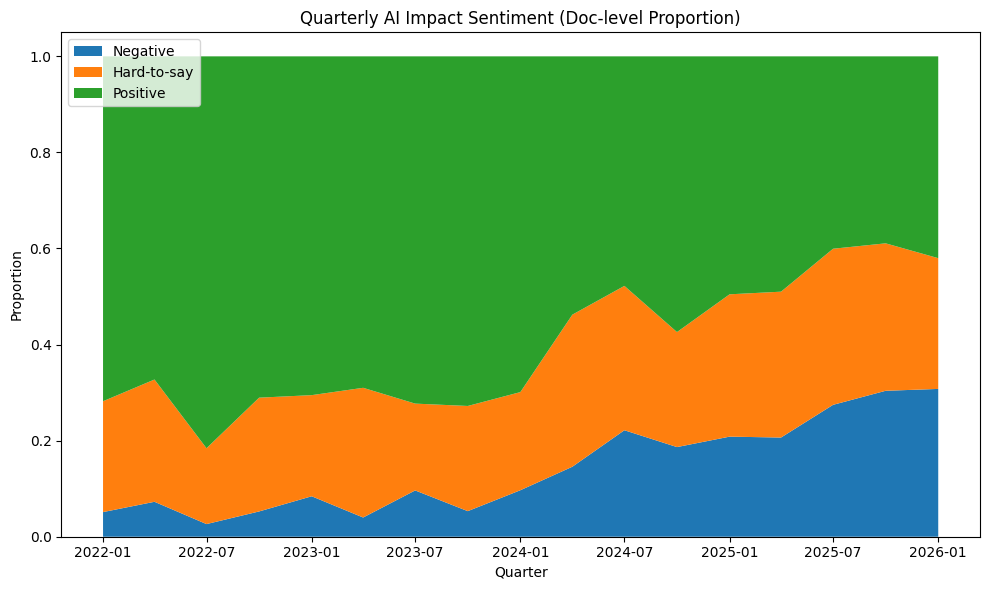

In [47]:
quarter_sent_prop = (
    quarter_sent_pivot
    .div(quarter_sent_pivot.sum(axis=1), axis=0)
)
plt.figure(figsize=(10,6))

plt.stackplot(
    quarter_sent_prop.index,
    quarter_sent_prop.get("negatively", 0),
    quarter_sent_prop.get("hard-to-say", 0),
    quarter_sent_prop.get("positively", 0),
    labels=["Negative", "Hard-to-say", "Positive"]
)

plt.legend(loc="upper left")
plt.title("Quarterly AI Impact Sentiment (Doc-level Proportion)")
plt.xlabel("Quarter")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()